# Step 6 - Mix Shift Walkthrough

This notebook is the teaching version of `src/06_mixshift.py`.

Audience:
- Readers who want to understand how the project turns a total-forecast scenario into an HS-code-level substitution argument.

Prerequisites:
- Familiarity with the ARIMA and ARIMAX forecast outputs
- A basic idea of HS 8542 versus HS 3818 within the project's import story

Learning goals:
- Understand how the BAU total forecast is split into HS-code components
- See how uploaded actuals create a measurable substitution delta
- Interpret the two mix-shift charts the dashboard relies on
- Save the same report and charts as the script


## Outline

1. Set up imports and load the annual data
2. Choose the available forecast source
3. Convert the total forecast into HS 8542 and HS 3818 BAU values
4. Load synthetic or uploaded actuals if available
5. Build the flagship substitution-delta chart
6. Build the HS-split comparison chart
7. Save the report and review the output artifacts
8. Try a short interpretation exercise


In [1]:
from pathlib import Path
import os
import sys
import warnings

candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT_ROOT = next(path for path in candidates if (path / "config.py").exists())
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from config import (
    ANNUAL_FILE,
    CHART_DIR,
    FORECAST_FILE_ARIMA,
    FORECAST_FILE_ARIMAX,
    REPORT_DIR,
    SYNTHETIC_FILE,
)

warnings.filterwarnings(
    "ignore",
    message="FigureCanvasAgg is non-interactive.*",
    category=UserWarning,
)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 140,
    "savefig.dpi": 140,
    "savefig.bbox": "tight",
})

NAVY = "#0f2744"
BLUE = "#1d4ed8"
TEAL = "#0d9488"
AMBER = "#f59e0b"
RED = "#dc2626"
GREEN = "#16a34a"
GRAY = "#64748b"

PROJECT_ROOT


WindowsPath('C:/Users/Pegasus/Desktop/SemiTrack2')

## Load the annual series and choose the forecast source

Mix-shift analysis starts from a total forecast. The script prefers ARIMAX when it exists and falls back to ARIMA otherwise.


In [2]:
ann = pd.read_csv(ANNUAL_FILE)
ann["year"] = ann["year"].astype(int)
ann = ann.sort_values("year").reset_index(drop=True)

for forecast_path, forecast_label in [(FORECAST_FILE_ARIMAX, "ARIMAX"), (FORECAST_FILE_ARIMA, "ARIMA")]:
    if os.path.exists(forecast_path):
        fc_df = pd.read_csv(forecast_path)
        fc_label = forecast_label
        break
else:
    raise FileNotFoundError("No forecast file found. Run steps 4 and 5 first.")

fc_col = next(column for column in fc_df.columns if "forecast" in column.lower())

pd.DataFrame(
    {
        "item": ["forecast source", "forecast column", "historical years"],
        "value": [fc_label, fc_col, f"{ann['year'].min()}-{ann['year'].max()}"],
    }
)


,item,value
0,forecast source,ARIMAX
1,forecast column,arimax_forecast_bn
2,historical years,1995-2024


## Use the last historical HS split as the BAU mix assumption

The total forecast does not say how much should land in HS 8542 versus HS 3818. This step creates a business-as-usual split using the latest historical composition.


In [3]:
last = ann.iloc[-1]
split_8542 = last["hs8542_import_usd"] / last["total_import_value_usd"]
split_3818 = last["hs3818_import_usd"] / last["total_import_value_usd"]

pd.DataFrame(
    {
        "hs_code": ["8542", "3818"],
        "share_of_last_historical_total": [split_8542, split_3818],
        "interpretation": [
            "Share of finished-chip imports in the last historical year",
            "Share of raw-input imports in the last historical year",
        ],
    }
)


,hs_code,share_of_last_historical_total,interpretation
0,8542,0.9918,Share of finished-chip imports in the last his...
1,3818,0.0082,Share of raw-input imports in the last histori...


## Build the BAU forecast table by HS code

Now we take the total forecast for each future year and allocate it across HS 8542 and HS 3818 using the historical split we just computed.


In [4]:
bau = {}
for _, row in fc_df.iterrows():
    year = int(row["year"])
    total = row[fc_col]
    bau[year] = {
        "total": total,
        "hs8542_bn": round(total * split_8542, 4),
        "hs3818_bn": round(total * split_3818, 4),
        "ci_lo": row["ci_lower_bn"],
        "ci_hi": row["ci_upper_bn"],
    }

bau_df = pd.DataFrame(
    [
        {
            "year": year,
            "bau_total_bn": values["total"],
            "bau_hs8542_bn": values["hs8542_bn"],
            "bau_hs3818_bn": values["hs3818_bn"],
            "ci_lower_bn": values["ci_lo"],
            "ci_upper_bn": values["ci_hi"],
        }
        for year, values in bau.items()
    ]
)
bau_df


,year,bau_total_bn,bau_hs8542_bn,bau_hs3818_bn,ci_lower_bn,ci_upper_bn
0,2025,13.9312,13.8173,0.1139,9.8917,19.6203
1,2026,14.1557,14.0400,0.1157,10.0302,19.9780
2,2027,14.0785,13.9634,0.1151,9.9826,19.8549


## Load synthetic or uploaded actuals

The substitution argument only becomes testable when actuals are available. This notebook looks for the synthetic actuals file first, but the same code works with later uploaded real data in the same format.


In [5]:
actuals = {}
synthetic_df = None
if os.path.exists(SYNTHETIC_FILE):
    synthetic_df = pd.read_csv(SYNTHETIC_FILE)
    value_column = next(
        (column for column in synthetic_df.columns if "actual" in column.lower() and "bn" in column.lower()),
        None,
    )
    if value_column:
        for _, row in synthetic_df.iterrows():
            key = (int(row["year"]), str(row["period"]).lower().strip(), str(row["hs_code"]).strip())
            actuals[key] = float(row[value_column])

if synthetic_df is not None:
    synthetic_df
else:
    pd.DataFrame({"note": ["No synthetic or uploaded actuals found."]})


## Compute the substitution delta for 2025 when actuals are present

The flagship delta is simply the BAU total forecast minus the actual total. A positive delta means actual imports came in below the import-heavy baseline, which is the direction we would expect under successful domestic substitution.


In [6]:
deltas = {}
actual_8542_2025 = actuals.get((2025, "full_year", "8542"))
actual_3818_2025 = actuals.get((2025, "full_year", "3818"))

if actual_8542_2025 is not None and actual_3818_2025 is not None:
    total_actual = actual_8542_2025 + actual_3818_2025
    bau_total = bau[2025]["total"]
    deltas[2025] = bau_total - total_actual
else:
    total_actual = None
    bau_total = None

pd.DataFrame(
    {
        "metric": ["2025 BAU total", "2025 actual total", "2025 substitution delta"],
        "value": [bau_total, total_actual, deltas.get(2025)],
    }
)


,metric,value
0,2025 BAU total,13.9312
1,2025 actual total,13.4581
2,2025 substitution delta,0.4731


## Plot 1 - the flagship substitution-delta chart

The top panel compares historical values, the BAU forecast, and the actual 2025 point if available. The bottom panel converts that gap into a direct delta bar so the substitution story is easier to read quickly.


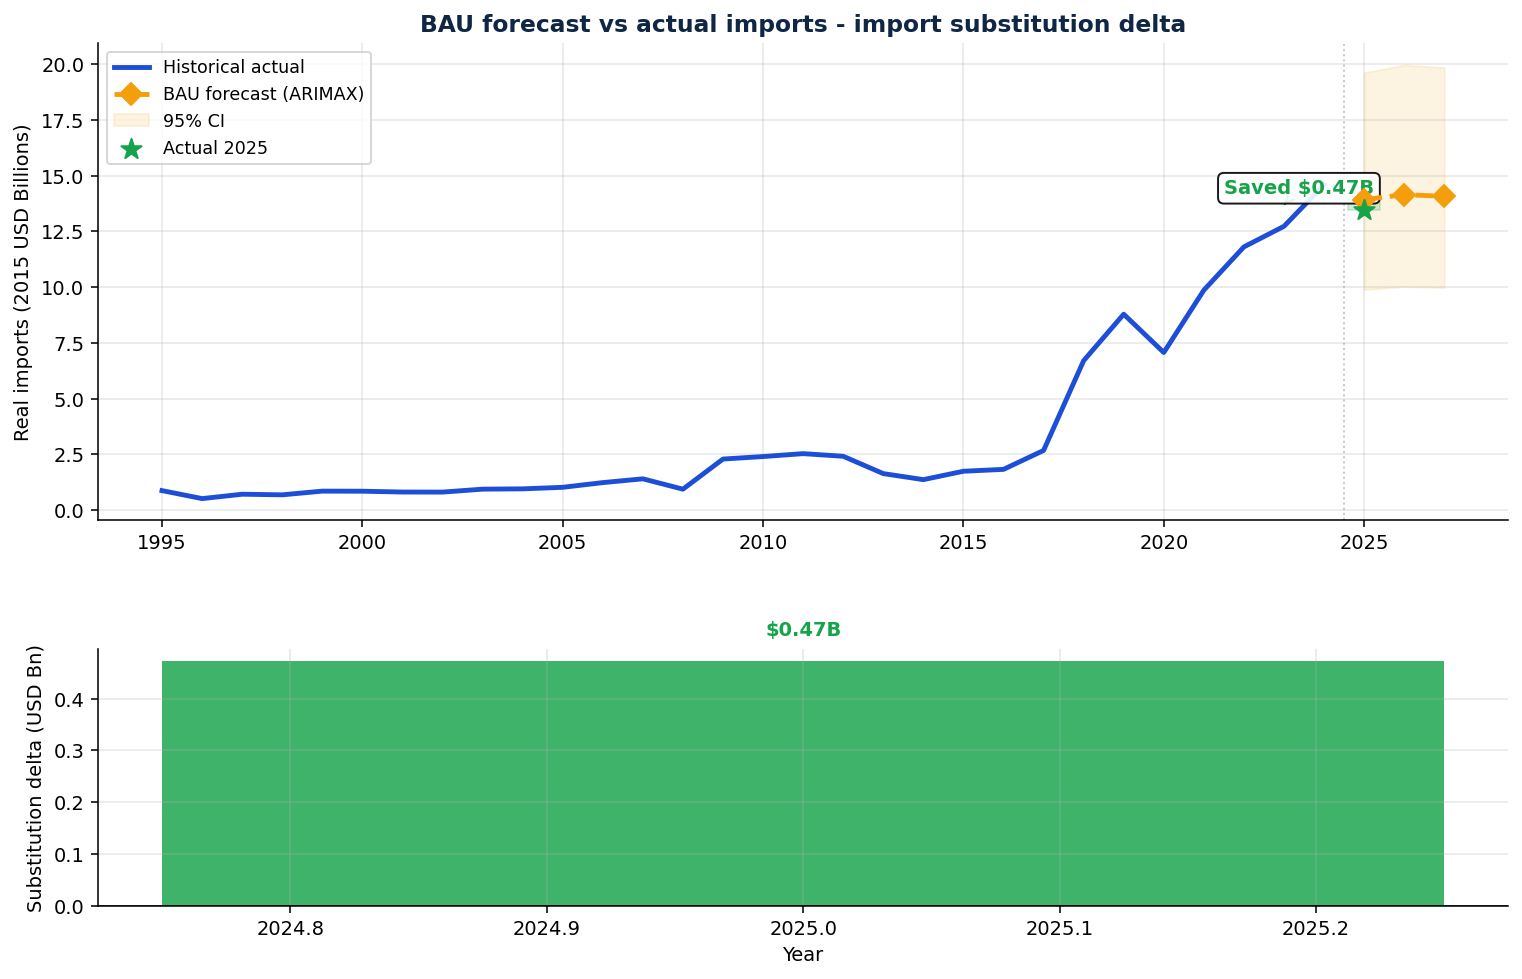

In [7]:
chart_01 = Path(CHART_DIR) / "mixshift_01_delta.png"
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(13, 8), gridspec_kw={"height_ratios": [0.65, 0.35]})
plt.subplots_adjust(hspace=0.35)

real_vals = ann["real_value_2015usd_billions"].to_numpy()
ax_top.plot(ann["year"], real_vals, color=BLUE, lw=2.5, label="Historical actual", zorder=3)
ax_top.plot(fc_df["year"], fc_df[fc_col], color=AMBER, lw=2.5, linestyle="--", marker="D", markersize=8, label=f"BAU forecast ({fc_label})", zorder=4)
ax_top.fill_between(fc_df["year"], fc_df["ci_lower_bn"], fc_df["ci_upper_bn"], color=AMBER, alpha=0.12, label="95% CI")
ax_top.axvline(2024.5, color=GRAY, lw=1, linestyle=":", alpha=0.4)

if total_actual is not None:
    ax_top.scatter([2025], [total_actual], color=GREEN, s=120, zorder=5, marker="*", label="Actual 2025")
    ax_top.fill_between([2024.6, 2025.4], [total_actual, total_actual], [bau_total, bau_total], color=GREEN, alpha=0.18)
    ax_top.annotate(
        f"Saved ${deltas[2025]:.2f}B",
        (2023, (bau_total + total_actual) / 2),
        xytext=(2021.5, (bau_total + total_actual) / 2 + 0.5),
        arrowprops=dict(arrowstyle="->", color=GREEN, lw=1.2),
        fontsize=10,
        fontweight="bold",
        color=GREEN,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9),
    )

ax_top.set_ylabel("Real imports (2015 USD Billions)")
ax_top.set_title("BAU forecast vs actual imports - import substitution delta", fontsize=12, fontweight="bold", color=NAVY)
ax_top.legend(fontsize=9)

if deltas:
    delta_years = list(deltas.keys())
    delta_values = list(deltas.values())
    bar_colors = [GREEN if value > 0 else RED for value in delta_values]
    ax_bot.bar(delta_years, delta_values, color=bar_colors, alpha=0.82, width=0.5)
    for year, value in deltas.items():
        ax_bot.text(year, value + (0.05 if value >= 0 else -0.12), f"${value:.2f}B", ha="center", fontsize=10, color=GREEN if value >= 0 else RED, fontweight="bold")
else:
    ax_bot.text(2026, 0.5, "Upload actual CSV to reveal the substitution delta", ha="center", fontsize=10, color=GRAY)
    ax_bot.set_xlim(2024, 2028)

ax_bot.axhline(0, color=NAVY, lw=0.8)
ax_bot.set_ylabel("Substitution delta (USD Bn)")
ax_bot.set_xlabel("Year")
plt.savefig(chart_01)
plt.show()
plt.close(fig)


## Plot 2 - check both HS signals side by side

The substitution story is strongest when both signals appear together: finished-chip imports should come in below BAU while raw-input imports rise above BAU. This chart makes that logic explicit.


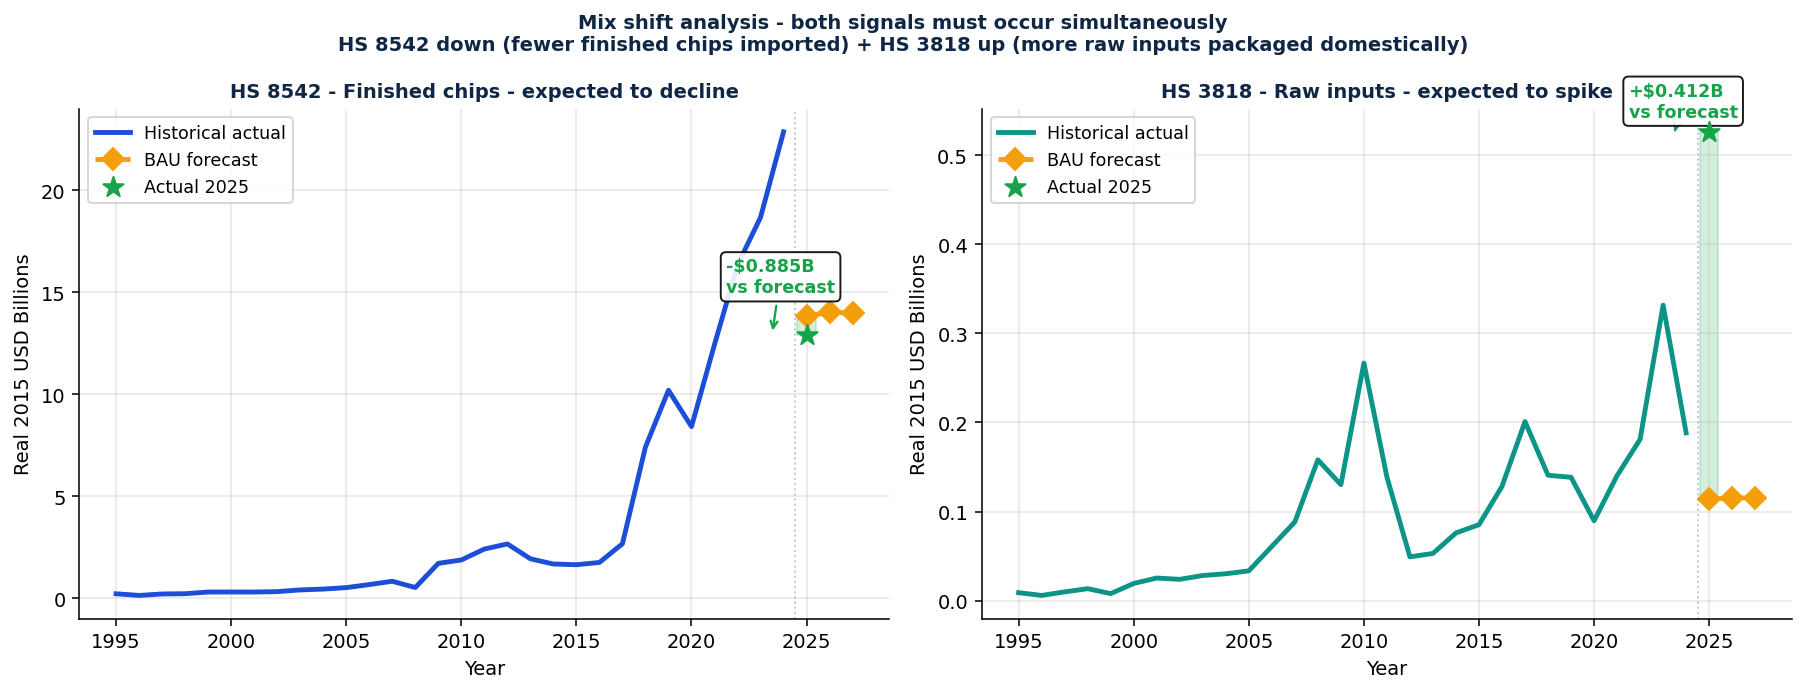

In [8]:
chart_02 = Path(CHART_DIR) / "mixshift_02_hs_split.png"
fig, (ax8, ax3) = plt.subplots(1, 2, figsize=(13, 5))

for ax, hs_code, hist_col, bau_key, direction, color, title_suffix in [
    (ax8, 8542, "hs8542_import_usd", "hs8542_bn", "down", BLUE, "Finished chips - expected to decline"),
    (ax3, 3818, "hs3818_import_usd", "hs3818_bn", "up", TEAL, "Raw inputs - expected to spike"),
]:
    hist = ann[hist_col] / 1e9
    bau_years = list(bau.keys())
    bau_values = [bau[year][bau_key] for year in bau_years]
    ax.plot(ann["year"], hist, color=color, lw=2.5, label="Historical actual")
    ax.plot(bau_years, bau_values, color=AMBER, lw=2.5, linestyle="--", marker="D", markersize=8, label="BAU forecast")
    ax.axvline(2024.5, color=GRAY, lw=1, linestyle=":", alpha=0.4)

    actual = actuals.get((2025, "full_year", str(hs_code)))
    if actual is not None:
        bau_2025 = bau[2025][bau_key]
        good_signal = (direction == "down" and actual < bau_2025) or (direction == "up" and actual > bau_2025)
        signal_color = GREEN if good_signal else RED
        diff = abs(bau_2025 - actual)
        sign = "-" if direction == "down" else "+"
        ax.scatter([2025], [actual], color=signal_color, s=120, zorder=5, marker="*", label="Actual 2025")
        ax.fill_between([2024.6, 2025.4], [actual, actual], [bau_2025, bau_2025], color=signal_color, alpha=0.18)
        ax.annotate(
            f"{sign}${diff:.3f}B\nvs forecast",
            (2023.5, actual),
            xytext=(2021.5, actual + bau_2025 * 0.15),
            arrowprops=dict(arrowstyle="->", color=signal_color, lw=1.2),
            fontsize=9,
            fontweight="bold",
            color=signal_color,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.9),
        )

    ax.set_title(f"HS {hs_code} - {title_suffix}", fontweight="bold", color=NAVY, fontsize=10)
    ax.set_xlabel("Year")
    ax.set_ylabel("Real 2015 USD Billions")
    ax.legend(fontsize=9)

fig.suptitle(
    "Mix shift analysis - both signals must occur simultaneously\nHS 8542 down (fewer finished chips imported) + HS 3818 up (more raw inputs packaged domestically)",
    fontsize=10,
    fontweight="bold",
    color=NAVY,
)
plt.tight_layout()
plt.savefig(chart_02)
plt.show()
plt.close(fig)


## Save the mix-shift report

The script writes a text report summarizing the BAU split and the detected delta. The notebook keeps that same artifact so the rest of the project can rely on it.


In [9]:
report_path = Path(REPORT_DIR) / "mixshift_report.txt"
report_lines = [
    "SEMITRACK INDIA - Mix Shift Report",
    "=" * 65,
    "",
    f"BAU forecast source: {fc_label}",
    f"HS 8542 split: {split_8542 * 100:.2f}%",
    f"HS 3818 split: {split_3818 * 100:.2f}%",
    "",
]
for year, values in bau.items():
    report_lines.append(
        f"{year}: total=${values['total']:.3f}B  HS 8542=${values['hs8542_bn']:.3f}B  HS 3818=${values['hs3818_bn']:.4f}B"
    )
if actuals:
    report_lines.append("")
    report_lines.append(f"Actual data loaded: {len(actuals)} entries")
    if deltas:
        for year, delta in deltas.items():
            report_lines.append(
                f"  {year} delta: ${delta:.3f}B  ({'SUBSTITUTION DETECTED' if delta > 0 else 'no signal'})"
            )
else:
    report_lines.append("")
    report_lines.append("No actual data uploaded yet.")
    report_lines.append("Upload data/synthetic/actual_imports_2025_2026.csv to test.")
report_path.write_text("\n".join(report_lines), encoding="utf-8")
str(report_path)


'C:\\Users\\Pegasus\\Desktop\\SemiTrack2\\outputs\\reports\\mixshift_report.txt'

## Review the saved output artifacts

A quick manifest helps connect the notebook to the pipeline outputs the dashboard or later analysis might read.


In [10]:
pd.DataFrame(
    {
        "artifact": ["Flagship delta chart", "HS split chart", "Mix shift report"],
        "path": [str(chart_01), str(chart_02), str(report_path)],
    }
)


,artifact,path
0,Flagship delta chart,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\ch...
1,HS split chart,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\ch...
2,Mix shift report,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\re...


In [11]:
# interpretation = "The strongest substitution signal appears only when finished-chip imports fall while raw-input imports rise. If one side is missing, the story is less convincing."
# print(interpretation)


## Common pitfall

A lower total import figure alone is not enough to prove substitution. The mix-shift step matters because it asks whether the composition of imports changed in the specific direction we would expect from domestic packaging or assembly activity.
